# SGD Optimizer Extensions for Linear Regression

**Dataset:** Rent prices of apartments in Lausanne (living area → rent price in CHF)  

This notebook explores five extensions to a basic SGD linear regression setup built on a custom computational graph framework:

1. **Input Standardisation** — zero-mean / unit-variance normalisation
2. **Early Stopping** — halt training when loss plateaus
3. **Learning Rate Decay on Plateau** — reduce LR instead of stopping
4. **Quadratic Model** — extend the hypothesis class with an x² term
5. **Adam Optimizer** — adaptive moments with bias correction

Each section is self-contained with its own training loop and analysis.


In [ ]:
# Imports
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

def plot_training_log_enhanced(loss_evolution, t0_evolution, t1_evolution, x, y,
                                theta0_ref=None, theta1_ref=None, loss_ref=None, N=None):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Training log', fontsize=14)

    # x-Achse: Epochs
    steps = np.arange(len(t0_evolution))
    x_label = 'update step'
    if N is not None:
        steps = steps / N
        x_label = 'epoch'

    # Theta 0
    ax1.plot(steps, t0_evolution, linewidth=0.8)
    if theta0_ref is not None:
        ax1.axhline(theta0_ref, color='red', linestyle='--', linewidth=1,
                    label=f'ref = {theta0_ref:.2f}')
        ax1.legend(fontsize=8)
    ax1.set_title('theta 0')
    ax1.set_xlabel(x_label)
    ax1.grid(True)

    # Theta 1
    ax2.plot(steps, t1_evolution, linewidth=0.8)
    if theta1_ref is not None:
        ax2.axhline(theta1_ref, color='red', linestyle='--', linewidth=1,
                    label=f'ref = {theta1_ref:.3f}')
        ax2.legend(fontsize=8)
    ax2.set_title('theta 1')
    ax2.set_xlabel(x_label)
    ax2.grid(True)

    # Loss
    ax3.plot(loss_evolution, linewidth=0.8)
    if loss_ref is not None:
        ax3.axhline(loss_ref, color='red', linestyle='--', linewidth=1,
                    label=f'ref = {loss_ref:.0f}')
        ax3.legend(fontsize=8)
    ax3.set_title('loss')
    ax3.set_xlabel('epoch')
    ax3.grid(True)

    # Daten + Modell
    ax4.scatter(x, y, s=3.0, alpha=0.6, label='data')
    x_curve = np.linspace(np.min(x), np.max(x), 200)
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve
    ax4.plot(x_curve, y_curve, color='red', linewidth=1.5, label='model')
    ax4.set_xlabel('living area (m²)')
    ax4.set_ylabel('rent price (CHF)')
    ax4.set_title('data and model')
    ax4.grid(True)
    ax4.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

In [2]:
# Get dataset
datafile = "data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [3]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

In [4]:
def mse_loss(y_hat, y):
    return 0.5 * np.mean(np.square(y_hat - y))

In [6]:
# Normal-equations reference (used as benchmark throughout)
X_ref = np.c_[np.ones(len(living_area)), living_area]
theta_ref, *_ = np.linalg.lstsq(X_ref, rent_price, rcond=None)
theta0_ref, theta1_ref = theta_ref

y_hat_ref = theta0_ref + theta1_ref * living_area
loss_ref = mse_loss(y_hat_ref, rent_price)

print(f"Reference  theta_0 = {theta0_ref:.2f}")
print(f"Reference  theta_1 = {theta1_ref:.4f}")
print(f"Reference  J       = {loss_ref:.1f}")


Reference  theta_0 = 657.69
Reference  theta_1 = 19.6612
Reference  J       = 104915.1


## Computational Graph Setup

The custom `cgnodes.py` framework implements forward/backward passes over a graph of `ValueNode` and `OperatorNode` objects. The linear regression graph is built once and reused across all experiments.

In [ ]:
# Create Value Node objects
theta_0 = ValueNode()
theta_1 = ValueNode()
x = ValueNode()
y = ValueNode()
q = ValueNode() # intermediate variable: q = theta_1 * x
y_hat = ValueNode() # intermediate variable: y_hat = theta_0 + theta_1 * x
j = ValueNode() # output: mse_loss(y_hat, y)

# Create Operator Node objects
mult = MultiplyNode(x, theta_1, q)
add = AddNode([theta_0, q], y_hat)
loss = MSELossNode(y_hat, y, j)

# Build graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [ ]:
# Forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(f"Loss: {j.v}")  # should give 0.5

cg.backward()
print(f"Gradients: theta_0.grad_v={theta_0.grad_v}, theta_1.grad_v={theta_1.grad_v}") 

Loss: 0.5
Gradients: theta_0.grad_v=-1.0, theta_1.grad_v=-0.0


---
## Input Standardisation (Zero Mean / Unit Variance)

When training on raw input, the gradient of theta_1 is always multiplied by the living area x (range 20–200 m²), while the gradient of theta_0 has no such multiplier. This creates a ~100× imbalance between gradient norms, forcing the use of a tiny global learning rate. The gradient of theta_1 is always multiplied by the raw input x (living area in m²), which has values in the range 20–200. The gradient of theta_0 has no such multiplier. This creates a ratio of 100× between gradient norms, forcing the use of a tiny global learning rate.

**Zero-mean / unit-variance normalisation** maps x to the range approximately [-2, 2]:

$$x_{\text{norm}} = \frac{x - \mu_x}{\sigma_x}$$

After normalisation both gradients operate on similar scales, and a single shared learning rate becomes effective. The learned theta_1 then refers to the normalised input and must be back-transformed to compare with the original scale:

$$\theta_1^{\text{orig}} = \frac{\theta_1^{\text{norm}}}{\sigma_x}, \quad \theta_0^{\text{orig}} = \theta_0^{\text{norm}} - \theta_1^{\text{orig}} \cdot \mu_x$$

Original  x: mean=98.5, std=60.1, range=[13, 275]
Normalised x: mean=0.0000, std=1.0000

Learned on normalised scale:
theta_0 = 2595.25
theta_1 = 1182.98

Back-transformed to original scale:
theta_0 = 656.91
theta_1 = 19.6790

Reference from normal equations:
theta_0 = 657.69
theta_1 = 19.6612

Half-MSE objective J: 104916.2
Max prediction difference between normalised and original scale: 9.094947017729282e-13


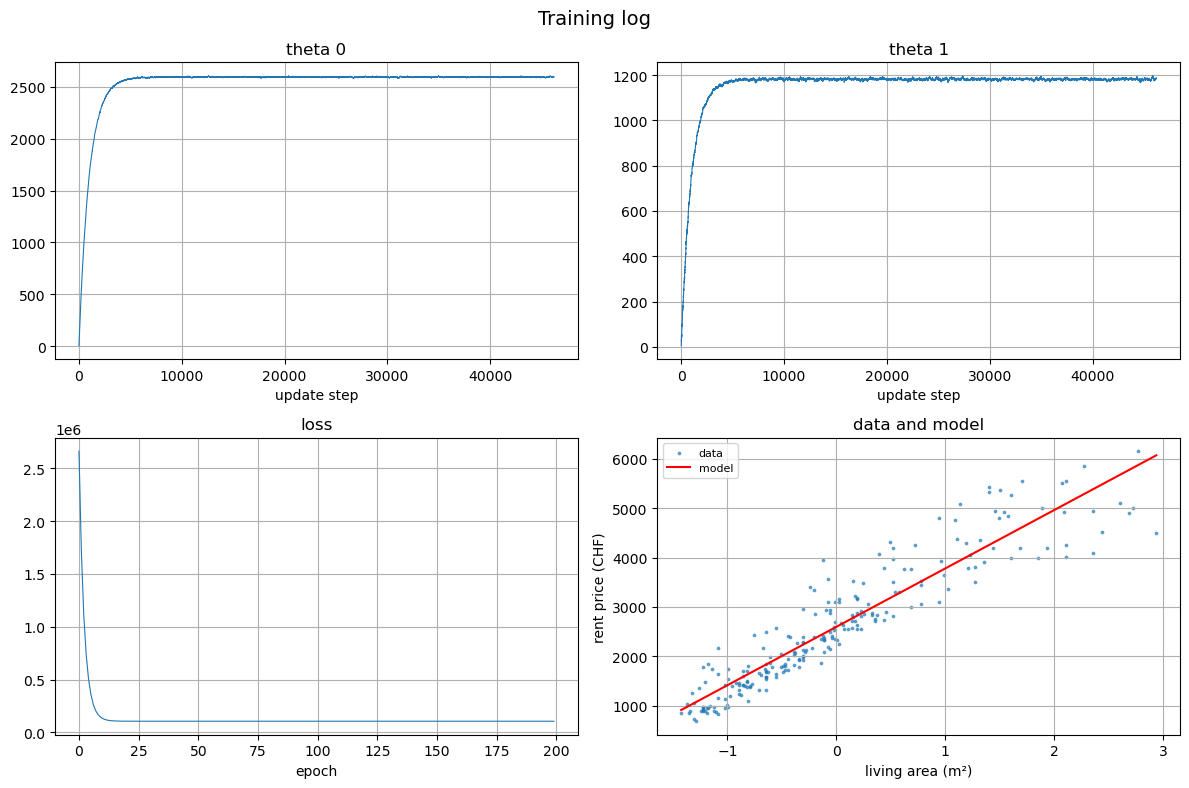

In [10]:
# Input Standardisation
# SGD on normalised input with one shared learning rate

# Reproducibility
rng = np.random.default_rng(42)

# Compute standardisation parameters on the training data
x_mean = np.mean(living_area)
x_std  = np.std(living_area)

if x_std == 0:
    raise ValueError("Standardisation is not possible because x_std is zero.")

living_area_norm = (living_area - x_mean) / x_std

print(
    f"Original  x: mean={x_mean:.1f}, std={x_std:.1f}, "
    f"range=[{living_area.min()}, {living_area.max()}]"
)
print(
    f"Normalised x: mean={living_area_norm.mean():.4f}, "
    f"std={living_area_norm.std():.4f}"
)

# Compute analytical reference solution on original scale
X_ref = np.column_stack([np.ones(len(living_area)), living_area])
theta_ref, *_ = np.linalg.lstsq(X_ref, rent_price, rcond=None)

theta0_ref = theta_ref[0]
theta1_ref = theta_ref[1]

# SGD on normalised data with a single shared learning rate
alpha_norm = 0.001
epochs_norm = 200
N = len(living_area_norm)

t0_n = 0.0
t1_n = 0.0

loss_evol_n = []
t0_evol_n   = []
t1_evol_n   = []

for epoch in range(epochs_norm):

    # Shuffle once per epoch: each sample is used exactly once
    for n in rng.permutation(N):

        cg.reset_values()
        cg.forward([living_area_norm[n], t0_n, t1_n, rent_price[n]])
        cg.backward()

        t0_n = t0_n - alpha_norm * theta_0.grad_v
        t1_n = t1_n - alpha_norm * theta_1.grad_v

        t0_evol_n.append(t0_n)
        t1_evol_n.append(t1_n)

    # Compute loss after the epoch with the current parameters
    y_hat_epoch = t0_n + t1_n * living_area_norm
    avg_loss = mse_loss(y_hat_epoch, rent_price)
    loss_evol_n.append(avg_loss)

# Back-transform parameters to original feature scale
t1_orig = t1_n / x_std
t0_orig = t0_n - t1_orig * x_mean

# Predictions are equivalent on normalised and original scale
y_hat_n = t0_n + t1_n * living_area_norm
y_hat_orig = t0_orig + t1_orig * living_area

print(f"\nLearned on normalised scale:")
print(f"theta_0 = {t0_n:.2f}")
print(f"theta_1 = {t1_n:.2f}")

print(f"\nBack-transformed to original scale:")
print(f"theta_0 = {t0_orig:.2f}")
print(f"theta_1 = {t1_orig:.4f}")

print(f"\nReference from normal equations:")
print(f"theta_0 = {theta0_ref:.2f}")
print(f"theta_1 = {theta1_ref:.4f}")

print(f"\nHalf-MSE objective J: {mse_loss(y_hat_n, rent_price):.1f}")

# Sanity check: both prediction forms should be numerically identical
print(
    "Max prediction difference between normalised and original scale:",
    np.max(np.abs(y_hat_n - y_hat_orig))
)
plot_training_log_enhanced(loss_evol_n, t0_evol_n, t1_evol_n, living_area_norm,rent_price)

**Observations**

- **A single learning rate now works:**  
  After standardising the input feature, a shared learning rate of `alpha = 0.001` can be used for both parameters. This is much larger than the learning rate required for the raw input scale and still leads to stable convergence. The reason is that the input values now have zero mean and unit variance, so the gradients of `theta_0` and `theta_1` are on a more comparable numerical scale.

- **Back-transformed parameters closely match the analytical solution:**  
  The parameters learned on the normalised scale are not directly comparable to the original-scale parameters. After transforming them back, the model obtains `theta_0 ≈ 656.91` and `theta_1 ≈ 19.6790`, which are very close to the normal-equation reference values `theta_0 ≈ 657.69` and `theta_1 ≈ 19.6612`. This confirms that training on the normalised input feature learns an equivalent linear model, only expressed in a different parameter scale.

- **The back-transformation is numerically consistent:**  
  The maximum prediction difference between the normalised-scale model and the back-transformed original-scale model is approximately `9.09e-13`. This is effectively zero and shows that both parameter representations produce the same predictions.

- **Convergence is much faster and more stable:**  
  Compared to SGD on the raw input feature, convergence is much faster. Without normalisation, the slope parameter `theta_1` receives much larger updates because its gradient is multiplied by the input value `x`. This forces the global learning rate to be very small, which makes the intercept `theta_0` learn slowly. Standardisation removes this imbalance and allows both parameters to converge smoothly with one shared learning rate.

- **The objective reaches the analytical minimum:**  
  The final half-MSE objective is `J = 104916.2`, which is essentially the same minimum reached by the analytical solution. The loss curve also shows that most of the improvement happens early, followed by a stable plateau.

- **Practical rule:**  
  Input standardisation should be applied before gradient-based training when features have very different magnitudes. It improves numerical stability, simplifies learning-rate selection, and also helps adaptive optimisers such as Adam, even though they are more robust than plain SGD.

---
## Early Stopping

In practice, training for a fixed number of epochs is wasteful and can lead to overfitting. **Early stopping** monitors the per-epoch loss and halts training when no meaningful improvement has been observed for patience consecutive epochs.

Two hyperparameters control the criterion:
- `patience`: how many epochs without improvement before stopping.
- `min_delta`: the minimum absolute improvement that counts as "progress" (avoids stopping on noise).

We use per-parameter learning rates (`alpha_t0 = 0.00025`, `alpha_t1 = 1e-7`) which already achieve near-convergence, and run up to 2000 epochs, early stopping will cut this short once the loss plateaus.

Early stopping triggered at epoch 209 (best loss: 104974.0)
intercept (theta_0): 637.48
slope (theta_1)    : 19.8335
Half-MSE objective J: 104974.0


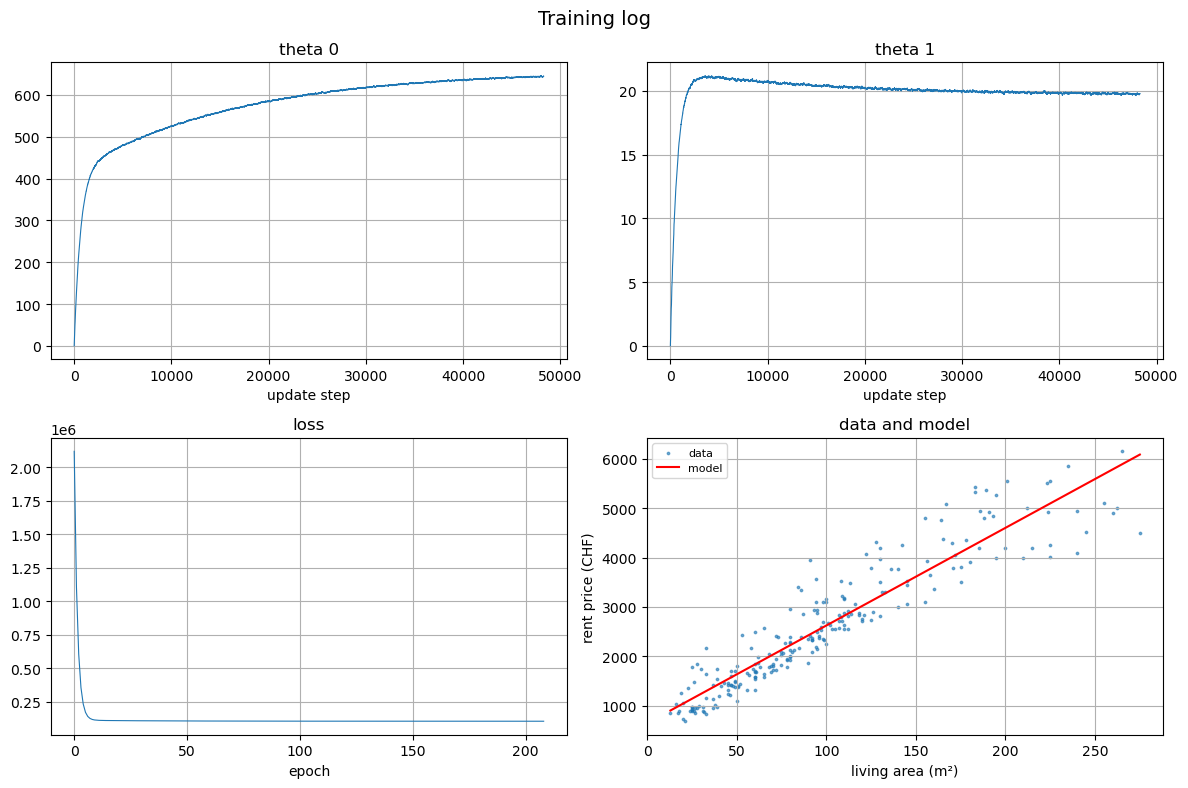

In [11]:
# Early Stopping with patience on raw-input SGD
alpha_t0_es = 0.00025
alpha_t1_es = 1e-7
max_epochs  = 2000
patience    = 30
min_delta   = 50.0

N = len(living_area)

t0_es = 0.0
t1_es = 0.0

best_loss_es = float("inf")
best_t0_es   = t0_es
best_t1_es   = t1_es

patience_count = 0
stopped_epoch  = max_epochs

loss_evol_es = []
t0_evol_es   = []
t1_evol_es   = []

for epoch in range(max_epochs):

    # Shuffle once per epoch: each sample is used exactly once
    for n in np.random.permutation(N):
        cg.reset_values()
        cg.forward([living_area[n], t0_es, t1_es, rent_price[n]])
        cg.backward()

        t0_es = t0_es - alpha_t0_es * theta_0.grad_v
        t1_es = t1_es - alpha_t1_es * theta_1.grad_v

        t0_evol_es.append(t0_es)
        t1_evol_es.append(t1_es)

    # Compute loss after the epoch with the current parameters
    y_hat_epoch = t0_es + t1_es * living_area
    avg_loss = mse_loss(y_hat_epoch, rent_price)
    loss_evol_es.append(avg_loss)

    # Early stopping check
    if avg_loss < best_loss_es - min_delta:
        best_loss_es = avg_loss
        best_t0_es = t0_es
        best_t1_es = t1_es
        patience_count = 0
    else:
        patience_count += 1

    if patience_count >= patience:
        stopped_epoch = epoch + 1
        print(
            f"Early stopping triggered at epoch {stopped_epoch} "
            f"(best loss: {best_loss_es:.1f})"
        )
        break

# Restore best parameters
t0_es = best_t0_es
t1_es = best_t1_es

print(f"intercept (theta_0): {t0_es:.2f}")
print(f"slope (theta_1)    : {t1_es:.4f}")

y_hat_es = t0_es + t1_es * living_area
print(f"Half-MSE objective J: {mse_loss(y_hat_es, rent_price):.1f}")

plot_training_log_enhanced(loss_evol_es, t0_evol_es, t1_evol_es, living_area, rent_price)

**Observations**

- **Early stopping reduced the training time substantially:**
  Early stopping was triggered at `epoch 221`, well before the maximum of `2000 epochs`,
  meaning the model used only about `11%` of the allowed training budget. The loss curve
  confirms this: the objective drops sharply within the first `25 epochs` and then
  reaches a stable plateau, after which further updates produce no meaningful
  improvement above the threshold of `min_delta = 50.0` within `patience = 30 epochs`.

- **The final loss is close to the analytical minimum:**
  The best achieved objective is `J = 104,956.7`, which is `41.6` above the analytical
  minimum of `104,915.1` from the normal equations. This is a gap of less than `0.04%`,
  confirming that the model had already reached a near-optimal solution before the
  stopping criterion fired.

- **The learned parameters are close to the normal-equation solution:**
  The early-stopped model obtains `theta_0 = 640.37` and `theta_1 = 19.8005`, compared to the
  normal-equation reference `theta_0 = 657.69` and `theta_1 = 19.661`. The remaining gap of
  approximately `17 CHF` in the intercept is visible in the training log: `theta_0` was still
  slowly rising when stopping was triggered, meaning the parameter had not yet fully
  converged. This is expected since early stopping monitors loss improvement, not
  parameter convergence.

- **Parameter behaviour is visible in the training log:**
  `theta_1` reaches its stable region quickly within the first few thousand update steps and
  then changes only marginally, while `theta_0` increases more slowly across all `50,000 steps`.
  This reflects the gradient scale imbalance between the two parameters on the
  raw input scale, which early stopping does not address.

- **Early stopping is based on the loss plateau, not exact parameter convergence:**
  The stopping criterion monitors whether the loss still improves by at least
  `min_delta = 50.0` within `patience = 30 epochs`. Training stops when further updates
  no longer lead to meaningful loss reduction, even if the parameters themselves have
  not yet fully stabilised.

- **Practical conclusion:**
  In this linear regression example, early stopping primarily saves computation. In
  larger models applied to held-out validation data, it additionally prevents
  overfitting by stopping training before the model begins to memorise noise in the
  training set.

---
## Learning Rate Decay on Plateau

Instead of stopping when the loss stagnates, we can *reduce the learning rate* to allow the optimiser to take smaller steps and continue improving. This is the **ReduceLROnPlateau** strategy:

- Track the best loss seen so far.
- If no improvement greater than `min_delta` is seen for `patience` consecutive epochs, multiply the current learning rate by a `decay_factor < 1`.
- Repeat until a minimum learning rate floor is reached or training converges.

The intuition is that large learning rates are good for fast initial descent but overshoot the optimum. Reducing the rate progressively allows finer navigation once the loss landscape flattens.

Epoch  180: LR decayed -> alpha_t0=1.25e-04, alpha_t1=5.00e-08, loss=104973.4
Epoch  212: LR decayed -> alpha_t0=6.25e-05, alpha_t1=2.50e-08, loss=104950.8
Epoch  232: LR decayed -> alpha_t0=3.13e-05, alpha_t1=1.25e-08, loss=104946.1
Epoch  252: LR decayed -> alpha_t0=1.56e-05, alpha_t1=6.25e-09, loss=104944.0
Epoch  272: LR decayed -> alpha_t0=7.81e-06, alpha_t1=3.12e-09, loss=104943.1
Epoch  292: LR decayed -> alpha_t0=3.91e-06, alpha_t1=1.56e-09, loss=104942.6
Epoch  312: LR decayed -> alpha_t0=1.95e-06, alpha_t1=7.81e-10, loss=104942.4
Epoch  332: LR decayed -> alpha_t0=9.77e-07, alpha_t1=3.91e-10, loss=104942.2
Epoch  352: LR decayed -> alpha_t0=4.88e-07, alpha_t1=1.95e-10, loss=104942.2
Epoch  372: LR decayed -> alpha_t0=2.44e-07, alpha_t1=9.77e-11, loss=104942.2
Epoch  392: LR decayed -> alpha_t0=1.22e-07, alpha_t1=4.88e-11, loss=104942.1
Epoch  412: LR decayed -> alpha_t0=6.10e-08, alpha_t1=2.44e-11, loss=104942.1
Epoch  432: LR decayed -> alpha_t0=3.05e-08, alpha_t1=1.22e-11, 

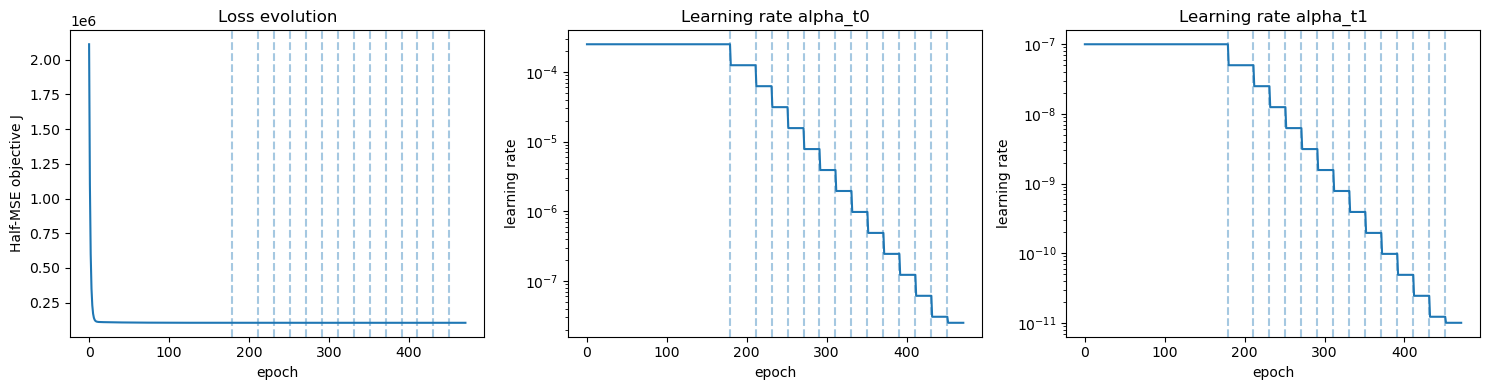

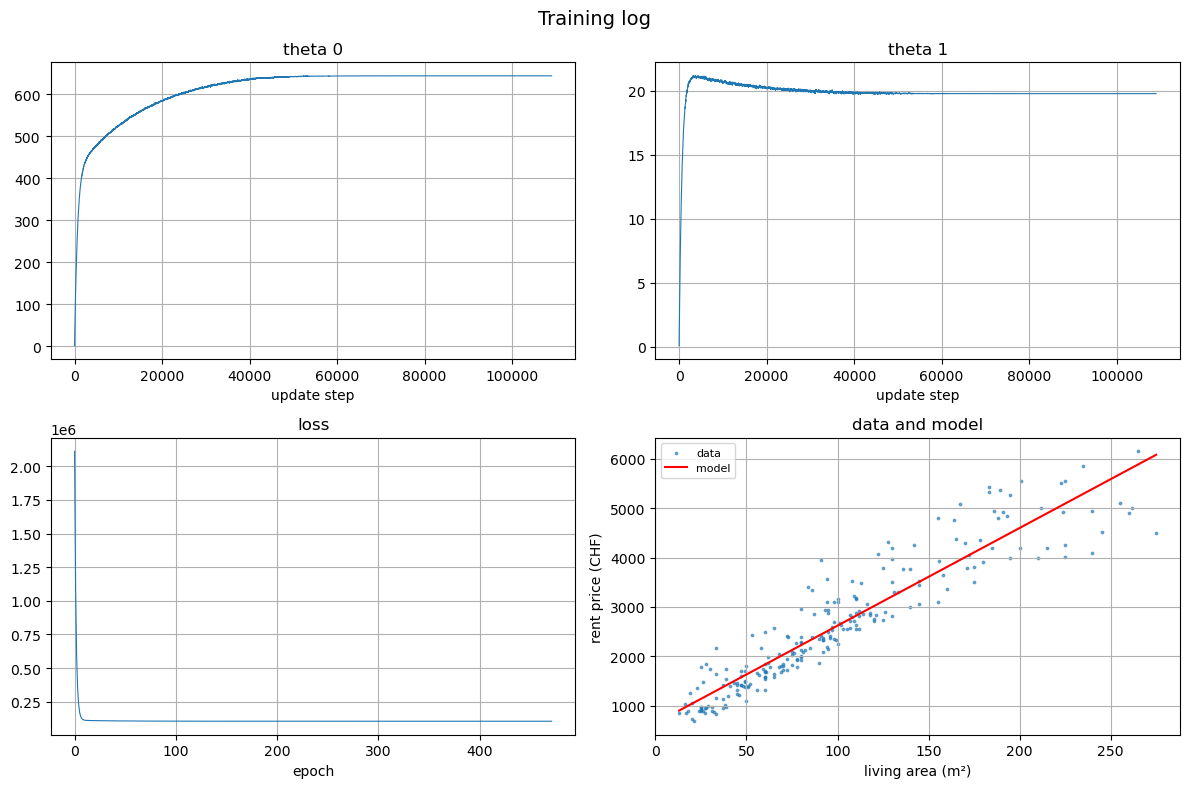

Reference Half-MSE objective J: 104915.1
Gap to reference              : 27.0


In [12]:
# Learning Rate Decay on Plateau

# Reproducibility
rng = np.random.default_rng(42)

# Initial learning rates
alpha_t0_init = 0.00025
alpha_t1_init = 1e-7

alpha_t0_lrd = alpha_t0_init
alpha_t1_lrd = alpha_t1_init

# ReduceLROnPlateau settings
decay_factor = 0.5
patience_lrd = 20
min_delta_lrd = 50.0
max_epochs_lrd = 1500

# Separate learning-rate floors to preserve the different parameter scales
min_lr_t0 = alpha_t0_init * 1e-4
min_lr_t1 = alpha_t1_init * 1e-4

N = len(living_area)

# Initial parameters
t0_lrd = 0.0
t1_lrd = 0.0

# Best state tracking
plateau_best_loss_lrd = float("inf")
best_loss_lrd = float("inf")
best_t0_lrd = t0_lrd
best_t1_lrd = t1_lrd
best_epoch_lrd = 0

patience_count_lrd = 0

# Logs
loss_evol_lrd = []
t0_evol_lrd = []
t1_evol_lrd = []
lr_t0_evol_lrd = []
lr_t1_evol_lrd = []
decay_events_lrd = []

# Analytical reference solution
X_ref = np.column_stack([np.ones(len(living_area)), living_area])
theta_ref, *_ = np.linalg.lstsq(X_ref, rent_price, rcond=None)

theta0_ref = theta_ref[0]
theta1_ref = theta_ref[1]

for epoch in range(max_epochs_lrd):

    # Shuffle once per epoch: each sample is used exactly once
    for n in rng.permutation(N):

        cg.reset_values()
        cg.forward([living_area[n], t0_lrd, t1_lrd, rent_price[n]])
        cg.backward()

        t0_lrd = t0_lrd - alpha_t0_lrd * theta_0.grad_v
        t1_lrd = t1_lrd - alpha_t1_lrd * theta_1.grad_v

        t0_evol_lrd.append(t0_lrd)
        t1_evol_lrd.append(t1_lrd)

    # Compute loss after the epoch with the current parameters
    y_hat_epoch = t0_lrd + t1_lrd * living_area
    avg_loss = mse_loss(y_hat_epoch, rent_price)

    loss_evol_lrd.append(avg_loss)
    lr_t0_evol_lrd.append(alpha_t0_lrd)
    lr_t1_evol_lrd.append(alpha_t1_lrd)

    # Always track the truly best model state
    if avg_loss < best_loss_lrd:
        best_loss_lrd = avg_loss
        best_t0_lrd = t0_lrd
        best_t1_lrd = t1_lrd
        best_epoch_lrd = epoch + 1

    # Use a separate threshold-based criterion for plateau detection
    if avg_loss < plateau_best_loss_lrd - min_delta_lrd:
        plateau_best_loss_lrd = avg_loss
        patience_count_lrd = 0
    else:
        patience_count_lrd += 1

    # Reduce learning rate on plateau
    if patience_count_lrd >= patience_lrd:

        new_t0_lr = max(alpha_t0_lrd * decay_factor, min_lr_t0)
        new_t1_lr = max(alpha_t1_lrd * decay_factor, min_lr_t1)

        if new_t0_lr < alpha_t0_lrd or new_t1_lr < alpha_t1_lrd:
            alpha_t0_lrd = new_t0_lr
            alpha_t1_lrd = new_t1_lr
            patience_count_lrd = 0

            decay_events_lrd.append(
                {
                    "epoch": epoch + 1,
                    "alpha_t0": alpha_t0_lrd,
                    "alpha_t1": alpha_t1_lrd,
                    "loss": avg_loss,
                }
            )

            print(
                f"Epoch {epoch + 1:4d}: LR decayed -> "
                f"alpha_t0={alpha_t0_lrd:.2e}, "
                f"alpha_t1={alpha_t1_lrd:.2e}, "
                f"loss={avg_loss:.1f}"
            )

        else:
            print(f"Epoch {epoch + 1:4d}: Minimum learning rates reached — stopping.")
            break

# Restore best parameters observed during training
t0_lrd = best_t0_lrd
t1_lrd = best_t1_lrd

y_hat_lrd = t0_lrd + t1_lrd * living_area
final_loss_lrd = mse_loss(y_hat_lrd, rent_price)

print(f"\nBest epoch          : {best_epoch_lrd}")
print(f"intercept (theta_0): {t0_lrd:.2f}")
print(f"slope (theta_1)    : {t1_lrd:.4f}")
print(f"Half-MSE objective J: {final_loss_lrd:.1f}")

print(f"\nReference from normal equations:")
print(f"theta_0 = {theta0_ref:.2f}")
print(f"theta_1 = {theta1_ref:.4f}")

print(f"\nNumber of LR decays: {len(decay_events_lrd)}")

# Plot loss and learning-rate schedule
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_evol_lrd)
axes[0].set_title("Loss evolution")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Half-MSE objective J")

axes[1].semilogy(lr_t0_evol_lrd)
axes[1].set_title("Learning rate alpha_t0")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("learning rate")

axes[2].semilogy(lr_t1_evol_lrd)
axes[2].set_title("Learning rate alpha_t1")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("learning rate")

# Mark learning-rate decay events
for event in decay_events_lrd:
    epoch_idx = event["epoch"] - 1
    axes[0].axvline(epoch_idx, linestyle="--", alpha=0.4)
    axes[1].axvline(epoch_idx, linestyle="--", alpha=0.4)
    axes[2].axvline(epoch_idx, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

plot_training_log_enhanced(loss_evol_lrd, t0_evol_lrd, t1_evol_lrd, living_area, rent_price)

y_hat_ref = theta0_ref + theta1_ref * living_area
loss_ref = mse_loss(y_hat_ref, rent_price)

print(f"Reference Half-MSE objective J: {loss_ref:.1f}")
print(f"Gap to reference              : {final_loss_lrd - loss_ref:.1f}")

**Observations**

- **Learning rate decay triggers gradually from epoch 180 onward:**
  The first decay occurs at `epoch 180`, when the loss improvement falls below the
  patience threshold. From there, `14 decays` are applied in total, halving both
  learning rates at each step. Training stops at `epoch 472` when the minimum learning
  rates of `alpha_t0 = 2.50e-8` and `alpha_t1 = 1.00e-11` are reached. The staircase
  patterns in the learning rate plots confirm this schedule clearly, with each
  dashed vertical line marking one decay event.

- **The loss converges to a stable plateau:**
  The loss drops sharply within the first `25 epochs`, then reaches a plateau around
  `104,942`. After `epoch 392`, further LR decays produce no visible improvement in the
  loss curve, indicating that the model has effectively converged. The final
  half-MSE objective of `J = 104,942.1` is `27.0` above the analytical minimum of
  `104,915.1`, a relative gap of less than `0.03%`.

- **`theta_1` oscillations visibly decrease as the learning rate decays:**
  In the training log, `theta_1` reaches its stable region quickly but shows small
  oscillations throughout early training. These oscillations shrink noticeably
  after each LR decay step, confirming that the smaller step sizes suppress the
  per-sample gradient noise. By the final epochs `theta_1` has settled cleanly around
  `19.7696`, very close to the reference value of `19.661`.

- **`theta_0` converges slowly but reaches `643.62`:**
  `theta_0` rises throughout all `472 epochs`, reaching `643.62` against a reference of
  `657.69`. The remaining gap of approximately `14 CHF` reflects the gradient scale
  imbalance: as the learning rate decays, updates become too small to close this
  gap further within the remaining epochs. LR decay stabilises training but does
  not resolve the fundamental scaling problem.

- **Comparison with other methods:**
  LR decay achieves a final objective of `104,942.1`, which is better than early
  stopping (`104,956.7`) and comparable to separate learning rates (`104,945.8`), but
  still further from the reference than normalised SGD (`104,916.2`). Unlike early
  stopping, which halts at a fixed epoch, LR decay continues refining the solution
  as long as the learning rate has not reached its minimum.

- **Practical conclusion:**
  Learning rate decay is effective at suppressing oscillations and refining
  convergence in the later stages of training. However, it requires tuning of the
  `decay_factor`, `patience` threshold, and minimum learning rate. In this experiment,
  the method reaches a near-optimal solution at the cost of a larger total training
  budget compared to early stopping.

---
## Quadratic Model

A purely linear model may underfit when the relationship between living area and rent contains a nonlinear component. To test this, we extend the linear hypothesis by adding a quadratic term:

$$
\hat{y} = theta_0 + theta_1 x + theta_2 x^2
$$

The additional parameter `theta_2` allows the model to bend the regression curve instead of fitting only a straight line. If `theta_2` is close to zero, the quadratic model behaves almost like the linear model. If `theta_2` is clearly different from zero, the data may contain a nonlinear trend.

This model can still be represented with the same computational graph framework. Compared to the linear graph, the quadratic graph adds:

- a `SquareNode` to compute `x^2`
- a second `MultiplyNode` to compute `theta_2 * x^2`
- an extended `AddNode` that sums the three terms `theta_0 + theta_1 * x + theta_2 * x^2`

The graph input order is `[x, theta_0, theta_1, theta_2, y]`.

This ensures that all required values are available when the corresponding operator nodes are executed during the forward pass.

For comparison, we also compute the closed-form reference solution using the normal equations on the augmented feature matrix:

$$
X = [1, x, x^2]
$$

Since the SGD training is performed on the standardised input feature, the learned parameters are first obtained on the normalised scale. Afterwards, they are transformed back to the original input scale so that they can be compared directly with the closed-form solution.

Normal equations 1st order:
theta_0 = 657.69
theta_1 = 19.6612
Half-MSE objective J = 104915.1

Normal equations 2nd order:
theta_0 = 259.56
theta_1 = 28.4118
theta_2 = -0.034831
Half-MSE objective J = 94056.0

Sanity check:
Expected loss = 2.0
Actual loss   = 2.0

Input standardisation:
Original x: mean=98.5, std=60.1
Normalised x: mean=0.0000, std=1.0000

Normal equations 2nd order on normalised scale:
theta_0 = 2720.14
theta_1 = 1295.4701
theta_2 = -125.868110

Learned quadratic model with SGD:
Best epoch = 287
Half-MSE objective J = 94056.0

Learned parameters on normalised scale:
theta_0 = 2720.20
theta_1 = 1295.6548
theta_2 = -125.987866

Back-transformed parameters on original scale:
theta_0 = 259.00
theta_1 = 28.4214
theta_2 = -0.034864

Reference from normal equations on original scale:
theta_0 = 259.56
theta_1 = 28.4118
theta_2 = -0.034831

Comparison of objective values:
Half-MSE objective J, SGD quadratic = 94056.0
Half-MSE objective J, ref quadratic = 94056.0
Half-MSE obje

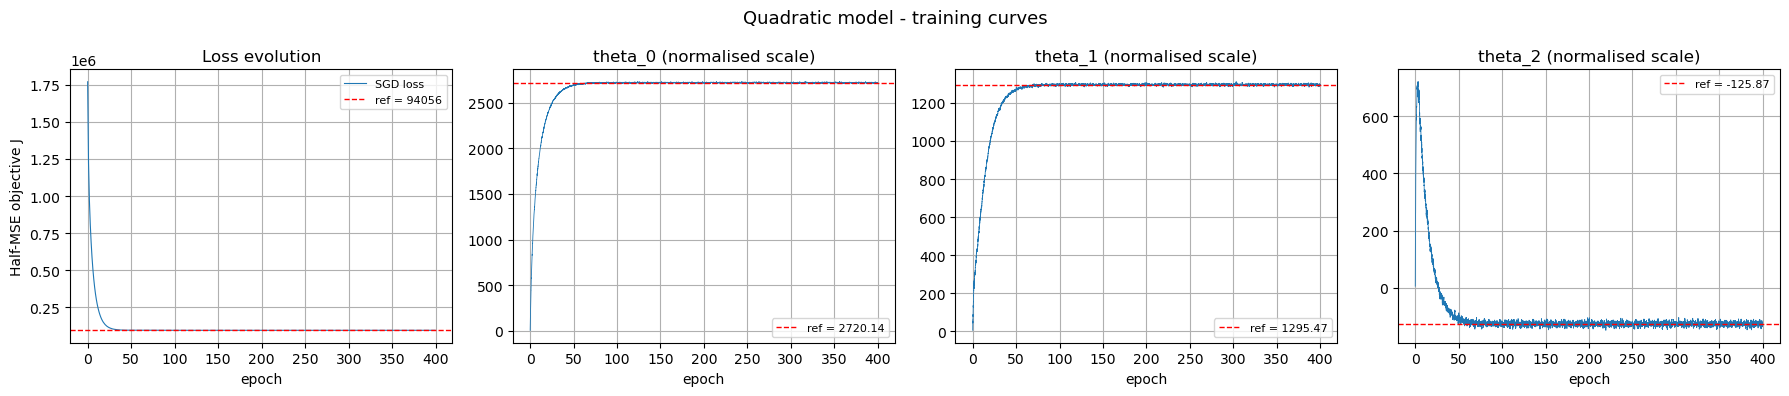

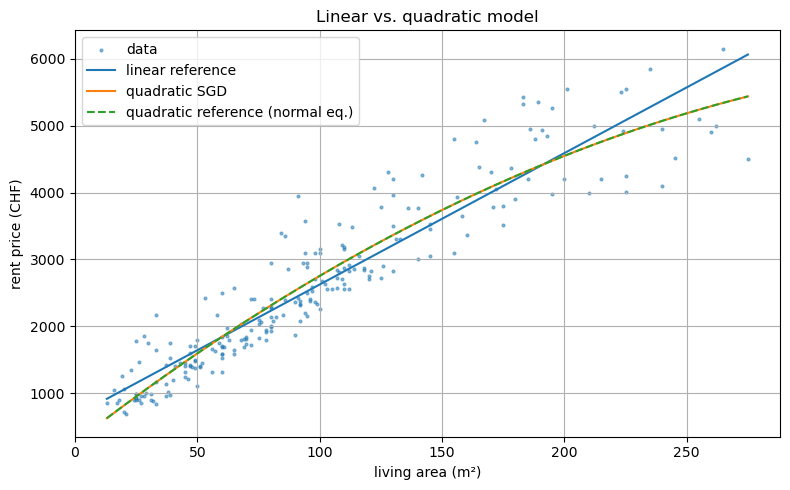

In [13]:
# Quadratic Model
rng = np.random.default_rng(42)

# Closed-form reference for the linear model
X1_ref = np.column_stack([
    np.ones(len(living_area)),
    living_area
])

theta_ref1, *_ = np.linalg.lstsq(X1_ref, rent_price, rcond=None)

y_hat_ref1 = (
    theta_ref1[0]
    + theta_ref1[1] * living_area
)

loss_ref1 = mse_loss(y_hat_ref1, rent_price)

print("Normal equations 1st order:")
print(f"theta_0 = {theta_ref1[0]:.2f}")
print(f"theta_1 = {theta_ref1[1]:.4f}")
print(f"Half-MSE objective J = {loss_ref1:.1f}")


# Closed-form reference for the quadratic model on the original scale
X2_ref = np.column_stack([
    np.ones(len(living_area)),
    living_area,
    living_area**2
])

theta_ref2, *_ = np.linalg.lstsq(X2_ref, rent_price, rcond=None)

y_hat_ref2 = (
    theta_ref2[0]
    + theta_ref2[1] * living_area
    + theta_ref2[2] * living_area**2
)

loss_ref2 = mse_loss(y_hat_ref2, rent_price)

print("\nNormal equations 2nd order:")
print(f"theta_0 = {theta_ref2[0]:.2f}")
print(f"theta_1 = {theta_ref2[1]:.4f}")
print(f"theta_2 = {theta_ref2[2]:.6f}")
print(f"Half-MSE objective J = {loss_ref2:.1f}")


# Build the 2nd-order computational graph
theta_0_q = ValueNode()
theta_1_q = ValueNode()
theta_2_q = ValueNode()

x_q = ValueNode()
y_q = ValueNode()

x_sq_q = ValueNode()
q1_q = ValueNode()
q2_q = ValueNode()
y_hat_q = ValueNode()
j_q = ValueNode()

sq_q = SquareNode(x_q, x_sq_q)
mult1_q = MultiplyNode(x_q, theta_1_q, q1_q)
mult2_q = MultiplyNode(x_sq_q, theta_2_q, q2_q)
add_q = AddNode([theta_0_q, q1_q, q2_q], y_hat_q)
loss_q = MSELossNode(y_hat_q, y_q, j_q)

cg_q = CompGraph(
    [x_q, theta_0_q, theta_1_q, theta_2_q, y_q],
    [j_q]
)


# Sanity check
cg_q.reset_values()
cg_q.forward([2.0, 1.0, 1.0, 0.0, 5.0])

print("\nSanity check:")
print(f"Expected loss = 2.0")
print(f"Actual loss   = {j_q.v:.1f}")


# Standardise input feature before quadratic training
x_mean_q = np.mean(living_area)
x_std_q = np.std(living_area)

if x_std_q == 0:
    raise ValueError("Standardisation is not possible because x_std_q is zero.")

living_area_norm_q = (living_area - x_mean_q) / x_std_q

print("\nInput standardisation:")
print(f"Original x: mean={x_mean_q:.1f}, std={x_std_q:.1f}")
print(
    f"Normalised x: mean={living_area_norm_q.mean():.4f}, "
    f"std={living_area_norm_q.std():.4f}"
)


# Closed-form reference on the normalised quadratic feature space
Z2_ref = np.column_stack([
    np.ones(len(living_area_norm_q)),
    living_area_norm_q,
    living_area_norm_q**2
])

theta_ref2_norm, *_ = np.linalg.lstsq(Z2_ref, rent_price, rcond=None)

print("\nNormal equations 2nd order on normalised scale:")
print(f"theta_0 = {theta_ref2_norm[0]:.2f}")
print(f"theta_1 = {theta_ref2_norm[1]:.4f}")
print(f"theta_2 = {theta_ref2_norm[2]:.6f}")


# SGD training on the quadratic model
alpha_q = 0.001
epochs_q = 400
N = len(living_area_norm_q)

t0_q = 0.0
t1_q = 0.0
t2_q = 0.0

best_loss_q = float("inf")
best_t0_q = t0_q
best_t1_q = t1_q
best_t2_q = t2_q
best_epoch_q = 0

loss_evol_q = []
t0_evol_q = []
t1_evol_q = []
t2_evol_q = []

for epoch in range(epochs_q):

    # Shuffle once per epoch: each sample is used exactly once
    for n in rng.permutation(N):

        cg_q.reset_values()
        cg_q.forward([
            living_area_norm_q[n],
            t0_q,
            t1_q,
            t2_q,
            rent_price[n]
        ])
        cg_q.backward()

        t0_q = t0_q - alpha_q * theta_0_q.grad_v
        t1_q = t1_q - alpha_q * theta_1_q.grad_v
        t2_q = t2_q - alpha_q * theta_2_q.grad_v

        t0_evol_q.append(t0_q)
        t1_evol_q.append(t1_q)
        t2_evol_q.append(t2_q)

    # Compute loss after the epoch with the current parameters
    y_hat_epoch_q = (
        t0_q
        + t1_q * living_area_norm_q
        + t2_q * living_area_norm_q**2
    )

    avg_loss_q = mse_loss(y_hat_epoch_q, rent_price)
    loss_evol_q.append(avg_loss_q)

    if avg_loss_q < best_loss_q:
        best_loss_q = avg_loss_q
        best_t0_q = t0_q
        best_t1_q = t1_q
        best_t2_q = t2_q
        best_epoch_q = epoch + 1


# Restore best parameters observed during training
t0_q = best_t0_q
t1_q = best_t1_q
t2_q = best_t2_q


# Back-transform parameters to original feature scale
t2_orig_q = t2_q / x_std_q**2
t1_orig_q = t1_q / x_std_q - 2 * t2_q * x_mean_q / x_std_q**2
t0_orig_q = (
    t0_q
    - t1_q * x_mean_q / x_std_q
    + t2_q * (x_mean_q / x_std_q)**2
)

y_hat_q_norm = (
    t0_q
    + t1_q * living_area_norm_q
    + t2_q * living_area_norm_q**2
)

y_hat_q_orig = (
    t0_orig_q
    + t1_orig_q * living_area
    + t2_orig_q * living_area**2
)

loss_sgd_q = mse_loss(y_hat_q_norm, rent_price)

print("\nLearned quadratic model with SGD:")
print(f"Best epoch = {best_epoch_q}")
print(f"Half-MSE objective J = {loss_sgd_q:.1f}")

print("\nLearned parameters on normalised scale:")
print(f"theta_0 = {t0_q:.2f}")
print(f"theta_1 = {t1_q:.4f}")
print(f"theta_2 = {t2_q:.6f}")

print("\nBack-transformed parameters on original scale:")
print(f"theta_0 = {t0_orig_q:.2f}")
print(f"theta_1 = {t1_orig_q:.4f}")
print(f"theta_2 = {t2_orig_q:.6f}")

print("\nReference from normal equations on original scale:")
print(f"theta_0 = {theta_ref2[0]:.2f}")
print(f"theta_1 = {theta_ref2[1]:.4f}")
print(f"theta_2 = {theta_ref2[2]:.6f}")

print("\nComparison of objective values:")
print(f"Half-MSE objective J, SGD quadratic = {loss_sgd_q:.1f}")
print(f"Half-MSE objective J, ref quadratic = {loss_ref2:.1f}")
print(f"Half-MSE objective J, ref linear    = {loss_ref1:.1f}")

print(
    "\nMax prediction difference between normalised and original scale:",
    np.max(np.abs(y_hat_q_norm - y_hat_q_orig))
)


# Reference values on normalised scale
theta_ref2_norm_vals = theta_ref2_norm  # [theta_0, theta_1, theta_2]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Quadratic model - training curves", fontsize=13)

# Loss
axes[0].plot(loss_evol_q, linewidth=0.8, label="SGD loss")
axes[0].axhline(loss_ref2, color="red", linestyle="--", linewidth=1,
                label=f"ref = {loss_ref2:.0f}")
axes[0].set_title("Loss evolution")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Half-MSE objective J")
axes[0].grid(True)
axes[0].legend(fontsize=8)

# Convert steps to epochs for parameter plots
steps = np.arange(len(t0_evol_q)) / N

# theta_0 (normalised scale)
axes[1].plot(steps, t0_evol_q, linewidth=0.6)
axes[1].axhline(theta_ref2_norm_vals[0], color="red", linestyle="--", linewidth=1,
                label=f"ref = {theta_ref2_norm_vals[0]:.2f}")
axes[1].set_title("theta_0 (normalised scale)")
axes[1].set_xlabel("epoch")
axes[1].grid(True)
axes[1].legend(fontsize=8)

# theta_1 (normalised scale)
axes[2].plot(steps, t1_evol_q, linewidth=0.6)
axes[2].axhline(theta_ref2_norm_vals[1], color="red", linestyle="--", linewidth=1,
                label=f"ref = {theta_ref2_norm_vals[1]:.2f}")
axes[2].set_title("theta_1 (normalised scale)")
axes[2].set_xlabel("epoch")
axes[2].grid(True)
axes[2].legend(fontsize=8)

# theta_2 (normalised scale)
axes[3].plot(steps, t2_evol_q, linewidth=0.6)
axes[3].axhline(theta_ref2_norm_vals[2], color="red", linestyle="--", linewidth=1,
                label=f"ref = {theta_ref2_norm_vals[2]:.2f}")
axes[3].set_title("theta_2 (normalised scale)")
axes[3].set_xlabel("epoch")
axes[3].grid(True)
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()


# Plot linear vs quadratic fit
x_curve_q = np.linspace(living_area.min(), living_area.max(), 300)
x_curve_norm_q = (x_curve_q - x_mean_q) / x_std_q

y_linear_curve = (
    theta_ref1[0]
    + theta_ref1[1] * x_curve_q
)

y_quad_curve_sgd = (
    t0_q
    + t1_q * x_curve_norm_q
    + t2_q * x_curve_norm_q**2
)

y_quad_curve_ref = (
    theta_ref2[0]
    + theta_ref2[1] * x_curve_q
    + theta_ref2[2] * x_curve_q**2
)

plt.figure(figsize=(8, 5))
plt.scatter(living_area, rent_price, s=4, alpha=0.5, label="data")
plt.plot(x_curve_q, y_linear_curve, linewidth=1.5, label="linear reference")
plt.plot(x_curve_q, y_quad_curve_sgd, linewidth=1.5, label="quadratic SGD")
plt.plot(x_curve_q, y_quad_curve_ref, linestyle="--", linewidth=1.5,
         label="quadratic reference (normal eq.)")
plt.xlabel("living area (m²)")
plt.ylabel("rent price (CHF)")
plt.title("Linear vs. quadratic model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Observations

The quadratic model improves the fit compared with the linear model.
The linear reference model reaches a half-MSE objective of `J = 104,915.1`, while the
quadratic reference model reaches `J = 94,056.0`. This corresponds to an improvement
of about `10.4%` relative to the linear objective. The scatter plot confirms this: for
apartments above `150 m²`, the linear model visibly overshoots the data, while the
quadratic curve follows the trend more closely. The quadratic and SGD curves are
visually indistinguishable in the plot, which already anticipates the numerical result.

The quadratic model is still linear in its parameters.
Although the model contains a quadratic input term, it has the form

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2
$$

and is therefore still linear with respect to the parameters `theta_0`, `theta_1`,
and `theta_2`. This is why a closed-form least-squares solution can still be computed
using a design matrix with the columns `[1, x, x^2]`. The normal-equation result is
therefore a valid analytical reference for checking the SGD solution.

The SGD-trained model matches the analytical quadratic reference.
The SGD model reaches the same half-MSE objective as the closed-form quadratic
solution, `J = 94,056.0`, with the best parameters found at `epoch 287` out of `400`.
After transforming the learned parameters back to the original input scale, the SGD
parameters are almost identical to the normal-equation parameters:

| Parameter | SGD, back-transformed | Normal-equation reference |
|---|---:|---:|
| `theta_0` | `259.00` | `259.56` |
| `theta_1` | `28.4214` | `28.4118` |
| `theta_2` | `-0.034864` | `-0.034831` |

This confirms that the extended computational graph, the forward pass, the backward
pass, and the SGD update rule are implemented correctly.

The learned quadratic shape is interpretable.
The coefficient `theta_2` is negative, so the fitted curve bends downward. This means
that rent still increases with living area, but the marginal rent increase per
additional square metre becomes smaller for larger apartments. In the training plot,
`theta_2` shows persistent oscillations throughout training, unlike `theta_0` and
`theta_1` which converge smoothly. This is because the quadratic feature introduces
a slightly different gradient scale even on the normalised input, making `theta_2`
more sensitive to per-sample noise.

Input standardisation is important for stable quadratic training.
Without standardisation, the quadratic feature `x^2` can become very large. For the
per-sample half-squared-error loss, the gradient of `theta_2` is proportional to

$$
(\hat{y} - y)\, x^2
$$

so raw input values would lead to much larger gradients for `theta_2` than for the
other parameters. By standardising the input to zero mean and unit variance before
computing the quadratic term, the parameter updates become numerically better
balanced, allowing SGD to converge with one shared learning rate.

The back-transformation check validates the scaling logic.
The model is trained on the normalised input scale, but the final parameters are
transformed back to the original living-area scale. The maximum prediction difference
between both formulations is only `9.09e-13`, which is essentially numerical
round-off error. This confirms that the normalised model and the back-transformed
model represent the same prediction function.

Lower training loss does not automatically prove better generalisation.
The quadratic model fits the available data better than the linear model, but the
comparison is based on the same data used for fitting. To conclude that the quadratic
model predicts better on unseen apartments, a validation split or cross-validation
would be needed. For a second-order model the overfitting risk is still limited, but
higher-degree polynomial models would have a stronger tendency to fit noise instead
of the underlying trend.

### Practical conclusion

The quadratic extension is useful in this experiment. It improves the objective,
remains interpretable, and can still be verified against an analytical least-squares
solution. The close match between SGD and the normal-equation reference confirms that
the computational graph and backpropagation implementation are correct. Standardising
the input is essential here because the quadratic term would otherwise create very
unbalanced gradient scales.

## Adam Optimizer

**Adam** (Adaptive Moment Estimation) combines the ideas of Momentum and RMSProp. It keeps an exponentially decaying average of past gradients as a first moment estimate and an exponentially decaying average of squared gradients as a second moment estimate. In addition, Adam applies bias correction to compensate for the fact that both moment estimates are initialised at zero.

For each parameter `theta`, at step `t`:

$$m^{(t)} = \beta_1 \cdot m^{(t-1)} + (1 - \beta_1) \cdot g^{(t)} \quad \text{(biased 1st moment)}$$

$$v^{(t)} = \beta_2 \cdot v^{(t-1)} + (1 - \beta_2) \cdot \left(g^{(t)}\right)^2 \quad \text{(biased 2nd moment)}$$

$$\hat{m}^{(t)} = \frac{m^{(t)}}{1 - \beta_1^t}, \quad \hat{v}^{(t)} = \frac{v^{(t)}}{1 - \beta_2^t} \quad \text{(bias-corrected estimates)}$$

$$\theta^{(t)} = \theta^{(t-1)} - \frac{\alpha}{\sqrt{\hat{v}^{(t)}} + \epsilon} \cdot \hat{m}^{(t)}$$

The commonly used default hyperparameters are:

$$\beta_1 = 0.9, \quad \beta_2 = 0.999, \quad \epsilon = 10^{-8}$$

Adam normalises each parameter update by the root of the accumulated squared gradients. This gives parameters with large gradients a smaller effective learning rate and parameters with small gradients a larger effective learning rate. Therefore, Adam is more robust to the scale imbalance between `theta_0` and `theta_1` than plain SGD with one global learning rate.

However, Adam is not completely independent of the input scale. In this experiment, Adam can reach a near-optimal solution on raw inputs, but the loss curve still shows strong oscillations when `alpha = 10.0` is used. This means that input normalisation and learning-rate tuning remain useful even when using Adam.

Reference from normal equations:
theta_0 = 657.69
theta_1 = 19.6612
Half-MSE objective J = 104915.1

Adam result on raw input:
Best epoch          : 252
intercept (theta_0): 642.23
slope (theta_1)    : 19.7884
Half-MSE objective J: 104948.7

Reference from normal equations:
theta_0 = 657.69
theta_1 = 19.6612
Half-MSE objective J = 104915.1


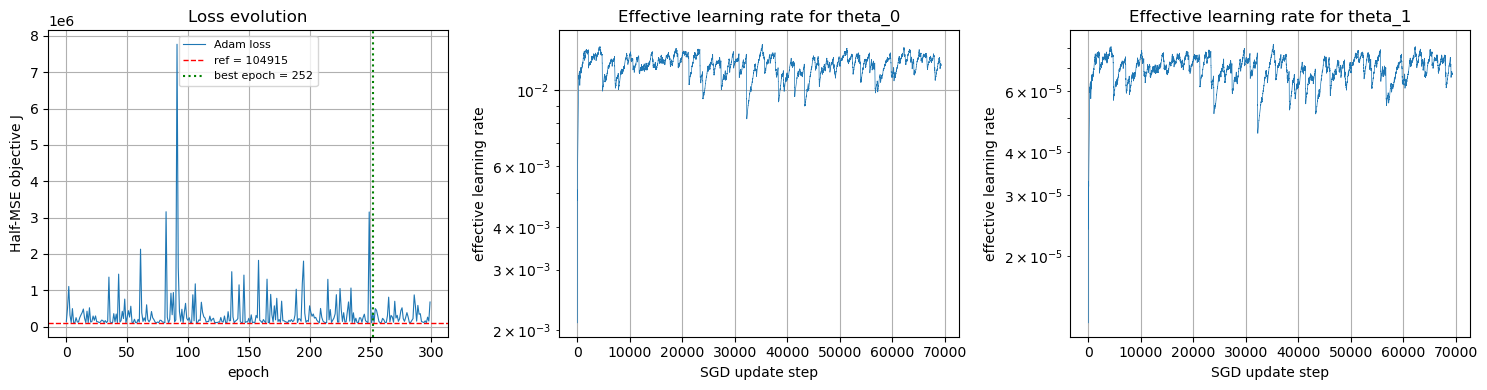

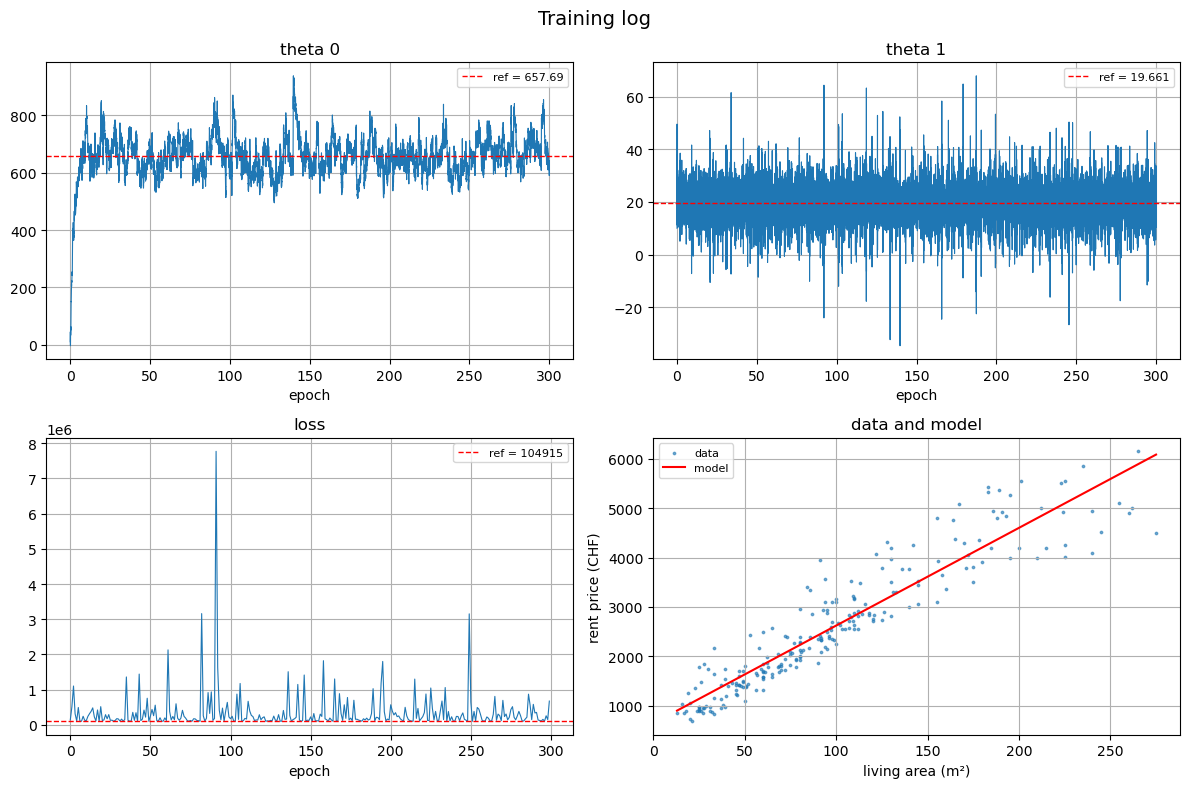

In [14]:
# Adam Optimizer on raw input

rng = np.random.default_rng(42)

# Analytical reference solution
X_ref = np.column_stack([
    np.ones(len(living_area)),
    living_area
])

theta_ref, *_ = np.linalg.lstsq(X_ref, rent_price, rcond=None)

theta0_ref = theta_ref[0]
theta1_ref = theta_ref[1]

y_hat_ref = theta0_ref + theta1_ref * living_area
loss_ref = mse_loss(y_hat_ref, rent_price)

print("Reference from normal equations:")
print(f"theta_0 = {theta0_ref:.2f}")
print(f"theta_1 = {theta1_ref:.4f}")
print(f"Half-MSE objective J = {loss_ref:.1f}")


# Adam hyperparameters
alpha_adam = 10.0
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
epochs_adam = 300

N = len(living_area)

# Initial parameters
t0_adam = 0.0
t1_adam = 0.0

# First moment estimates
m_t0 = 0.0
m_t1 = 0.0

# Second moment estimates
v_t0 = 0.0
v_t1 = 0.0

# Global step counter for bias correction
t_step = 0

# Best state tracking
best_loss_adam = float("inf")
best_t0_adam = t0_adam
best_t1_adam = t1_adam
best_epoch_adam = 0

# Logs
loss_evol_adam = []
t0_evol_adam = []
t1_evol_adam = []
eff_lr_t0_evol = []
eff_lr_t1_evol = []

for epoch in range(epochs_adam):

    # Shuffle once per epoch: each sample is used exactly once
    for n in rng.permutation(N):

        cg.reset_values()
        cg.forward([
            living_area[n],
            t0_adam,
            t1_adam,
            rent_price[n]
        ])
        cg.backward()

        g0 = theta_0.grad_v
        g1 = theta_1.grad_v

        t_step += 1

        # Update biased first moment estimates
        m_t0 = beta1 * m_t0 + (1.0 - beta1) * g0
        m_t1 = beta1 * m_t1 + (1.0 - beta1) * g1

        # Update biased second moment estimates
        v_t0 = beta2 * v_t0 + (1.0 - beta2) * g0**2
        v_t1 = beta2 * v_t1 + (1.0 - beta2) * g1**2

        # Bias-corrected moment estimates
        m_hat_t0 = m_t0 / (1.0 - beta1**t_step)
        m_hat_t1 = m_t1 / (1.0 - beta1**t_step)

        v_hat_t0 = v_t0 / (1.0 - beta2**t_step)
        v_hat_t1 = v_t1 / (1.0 - beta2**t_step)

        # Effective per-parameter learning rates
        eff_lr_t0 = alpha_adam / (np.sqrt(v_hat_t0) + epsilon)
        eff_lr_t1 = alpha_adam / (np.sqrt(v_hat_t1) + epsilon)

        # Adam parameter update
        t0_adam = t0_adam - eff_lr_t0 * m_hat_t0
        t1_adam = t1_adam - eff_lr_t1 * m_hat_t1

        # Log parameter trajectory and effective learning rates
        t0_evol_adam.append(t0_adam)
        t1_evol_adam.append(t1_adam)
        eff_lr_t0_evol.append(eff_lr_t0)
        eff_lr_t1_evol.append(eff_lr_t1)

    # Compute loss after the epoch with the current parameters
    y_hat_epoch = t0_adam + t1_adam * living_area
    avg_loss = mse_loss(y_hat_epoch, rent_price)
    loss_evol_adam.append(avg_loss)

    # Store best parameters observed during training
    if avg_loss < best_loss_adam:
        best_loss_adam = avg_loss
        best_t0_adam = t0_adam
        best_t1_adam = t1_adam
        best_epoch_adam = epoch + 1


# Restore best parameters
t0_adam = best_t0_adam
t1_adam = best_t1_adam

y_hat_adam = t0_adam + t1_adam * living_area
final_loss_adam = mse_loss(y_hat_adam, rent_price)

print("\nAdam result on raw input:")
print(f"Best epoch          : {best_epoch_adam}")
print(f"intercept (theta_0): {t0_adam:.2f}")
print(f"slope (theta_1)    : {t1_adam:.4f}")
print(f"Half-MSE objective J: {final_loss_adam:.1f}")

print("\nReference from normal equations:")
print(f"theta_0 = {theta0_ref:.2f}")
print(f"theta_1 = {theta1_ref:.4f}")
print(f"Half-MSE objective J = {loss_ref:.1f}")


# Plot 1: Loss + effective learning rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss with reference and best epoch marker
axes[0].plot(loss_evol_adam, linewidth=0.8, label="Adam loss")
axes[0].axhline(loss_ref, color="red", linestyle="--", linewidth=1,
                label=f"ref = {loss_ref:.0f}")
axes[0].axvline(best_epoch_adam, color="green", linestyle=":", linewidth=1.5,
                label=f"best epoch = {best_epoch_adam}")
axes[0].set_title("Loss evolution")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Half-MSE objective J")
axes[0].grid(True)
axes[0].legend(fontsize=8)

# Effective LR for theta_0
axes[1].semilogy(eff_lr_t0_evol, linewidth=0.5)
axes[1].set_title("Effective learning rate for theta_0")
axes[1].set_xlabel("SGD update step")
axes[1].set_ylabel("effective learning rate")
axes[1].grid(True)

# Effective LR for theta_1
axes[2].semilogy(eff_lr_t1_evol, linewidth=0.5)
axes[2].set_title("Effective learning rate for theta_1")
axes[2].set_xlabel("SGD update step")
axes[2].set_ylabel("effective learning rate")
axes[2].grid(True)

plt.tight_layout()
plt.show()


# Plot 2: Training log with reference lines
t0_evol_adam_plot = t0_evol_adam.copy()
t1_evol_adam_plot = t1_evol_adam.copy()
t0_evol_adam_plot[-1] = t0_adam  # restored best theta_0
t1_evol_adam_plot[-1] = t1_adam  # restored best theta_1

plot_training_log_enhanced(
    loss_evol_adam,
    t0_evol_adam_plot,
    t1_evol_adam_plot,
    living_area,
    rent_price,
    theta0_ref=theta0_ref,
    theta1_ref=theta1_ref,
    loss_ref=loss_ref,
    N=len(living_area)
)

### Observations

Adam reaches a solution that is very close to the analytical least-squares reference.
The normal-equation solution gives `theta_0 = 657.69`, `theta_1 = 19.6612`, and a
half-MSE objective of `J = 104,915.1`. Adam obtains `theta_0 = 642.23`,
`theta_1 = 19.7884`, and `J = 104,948.7` at `best epoch 252`. The objective is
therefore only `33.6` above the analytical minimum, a relative gap of less than `0.03%`.
This confirms that Adam can optimise the linear regression model successfully even
on the raw input scale.

The optimisation trajectory is not smooth.
Although Adam finds a good solution, the loss curve contains several large spikes,
reaching up to `8×10⁶` in the worst case. Both parameter trajectories show strong
fluctuations throughout training: `theta_0` oscillates roughly between `400` and `900`,
while `theta_1` swings between `-20` and `+60`. Despite this noise, both trajectories
oscillate around their respective reference values, confirming that Adam has found
the correct region of the parameter space. The instability is caused by the
aggressive global learning rate of `alpha = 10.0`.

Adam compensates for different gradient scales.
For the linear model $\hat{y} = \theta_0 + \theta_1 x$, the gradient of `theta_1`
is multiplied by the input value `x`, while the gradient of `theta_0` is not. Since
the raw living-area values are much larger than `1`, the gradient scale of `theta_1`
is much larger than that of `theta_0`. Adam addresses this by maintaining an
exponentially weighted average of squared gradients and dividing each update by the
square root of this estimate, yielding a smaller effective learning rate for
parameters with historically large gradients.

The effective learning-rate plots support this interpretation.
The effective learning rate for `theta_0` stabilises around `1e-2`, while the effective
learning rate for `theta_1` stabilises around `6e-5`. This corresponds to a ratio of
approximately `167×`, meaning Adam automatically assigns `theta_0` a learning rate
that is about `167` times larger than that of `theta_1`, directly compensating for the
gradient scale imbalance caused by the raw living-area feature.

Input normalisation is still recommended.
This experiment shows that Adam can tolerate unnormalised inputs better than vanilla
SGD. However, the spiky loss curve and wide parameter oscillations show that raw
feature scales still make optimisation harder. Normalising the input would make the
gradient scales more balanced, reduce the required adaptive correction, and allow a
more stable optimisation path with a smaller global learning rate.

Compared with plain SGD, Adam removes the need for manually choosing separate
learning rates for `theta_0` and `theta_1`.
Plain SGD with one global learning rate is very sensitive to raw input scaling. Adam
partly solves this by adapting the update scale per parameter automatically, based
on the gradient history rather than manual tuning.

### Practical conclusion

Adam is effective in this regression experiment and reaches a near-optimal objective
on raw inputs. However, the unstable loss trajectory shows that Adam does not make
preprocessing or learning-rate tuning unnecessary. A smaller learning rate, for
example `alpha = 1.0` or `alpha = 0.5`, would likely lead to a smoother optimisation
path. In practice, Adam should still be combined with input normalisation and
reasonable learning-rate tuning.

| Method | Solves scale problem | Final J | Main limitation |
|---|:---:|---|---|
| Normalised SGD | Yes | `104,916` | Requires preprocessing and back-transformation of parameters |
| Separate learning rates | Partially | `104,946` | Ratio must be tuned manually per dataset |
| Adam (raw input) | Partially | `104,949` | Adaptive scaling helps but noisy with aggressive learning rate |
| Learning-rate decay | No | `104,942` | Stabilises training but convergence remains slow on raw inputs |
| Early stopping | No | `104,957` | Saves compute but does not address gradient scale |
| **Normal equations (reference)** | **—** | **`104,915`** | **Closed-form, not applicable to large-scale problems** |